<a href="https://colab.research.google.com/github/mirnaelsheikhh/NLP-Fake-News-Detection/blob/main/tfidf_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn pandas numpy matplotlib joblib -q

import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

PREPROCESSED_PATH    = "/content/drive/MyDrive/dataset_preprocessed.csv"
MODEL_DIR            = "/content/drive/MyDrive/fake_news_models"
PLOTS_DIR            = "/content/drive/MyDrive/news_plots"
LOGISTIC_MODEL_PATH  = os.path.join(MODEL_DIR, "logistic_model.pkl")
NB_MODEL_PATH        = os.path.join(MODEL_DIR, "nb_model.pkl")
TFIDF_PATH           = os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")
BEST_MODEL_PATH      = os.path.join(MODEL_DIR, "best_model.pkl")
BEST_VECTORIZER_PATH = os.path.join(MODEL_DIR, "best_vectorizer.pkl")
PLOT_BASELINE_CMP    = os.path.join(PLOTS_DIR, "baseline_model_comparison.png")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
print("Setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete!


In [ ]:
print("Loading preprocessed dataset")
df = pd.read_csv(PREPROCESSED_PATH)

# Rebuild cleanText if needed
def parse_tokens(val):
    if isinstance(val, list): return val
    if isinstance(val, str):
        try: return ast.literal_eval(val)
        except: return val.split()
    return []


Loading preprocessed dataset


In [ ]:
df["preprocessingText2"] = df["preprocessingText2"].apply(parse_tokens)
df["cleanText"] = df["preprocessingText2"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)


In [ ]:
y = df["unreliable"]
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["cleanText"], y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 46733
Test size: 11684


In [ ]:
if os.path.exists(LOGISTIC_MODEL_PATH) and os.path.exists(TFIDF_PATH):
    print("Loading existing LR model and TF-IDF vectorizer")
    lr_model = joblib.load(LOGISTIC_MODEL_PATH)
    tfidf    = joblib.load(TFIDF_PATH)
    X_train  = tfidf.transform(X_train_text)
    X_test   = tfidf.transform(X_test_text)
else:
    print("Training Logistic Regression")
    tfidf   = TfidfVectorizer(max_features=1000, ngram_range=(1, 1))
    X_train = tfidf.fit_transform(X_train_text)
    X_test  = tfidf.transform(X_test_text)
    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train, y_train)
    joblib.dump(lr_model, LOGISTIC_MODEL_PATH)
    joblib.dump(tfidf,    TFIDF_PATH)
    print("Saved LR model and TF-IDF vectorizer.")

y_pred_lr = lr_model.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Training Logistic Regression
Saved LR model and TF-IDF vectorizer.
LR Accuracy: 0.9299897295446765
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      6316
           1       0.93      0.92      0.92      5368

    accuracy                           0.93     11684
   macro avg       0.93      0.93      0.93     11684
weighted avg       0.93      0.93      0.93     11684



In [ ]:
if os.path.exists(NB_MODEL_PATH):
    print("Loading existing Naive Bayes model")
    nb_model  = joblib.load(NB_MODEL_PATH)
    X_test_nb = tfidf.transform(X_test_text)
else:
    print("Training Naive Bayes...")
    nb_model  = MultinomialNB()
    nb_model.fit(X_train, y_train)
    joblib.dump(nb_model, NB_MODEL_PATH)
    print("Saved Naive Bayes model to Drive!")
    X_test_nb = X_test

y_pred_nb = nb_model.predict(X_test_nb)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Training Naive Bayes...
Saved Naive Bayes model to Drive!
Naive Bayes Accuracy: 0.8352447791852106
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      6316
           1       0.83      0.81      0.82      5368

    accuracy                           0.84     11684
   macro avg       0.83      0.83      0.83     11684
weighted avg       0.84      0.84      0.84     11684



In [ ]:
if os.path.exists(BEST_MODEL_PATH) and os.path.exists(BEST_VECTORIZER_PATH):
    print("Loading existing best model and vectorizer")
    best_model      = joblib.load(BEST_MODEL_PATH)
    best_vectorizer = joblib.load(BEST_VECTORIZER_PATH)
    X_test_best     = best_vectorizer.transform(X_test_text)
else:
    print("Running hyperparameter tuning")
    configurations = [
        (1000, (1,1)), (3000, (1,1)), (5000, (1,1)),
        (3000, (1,2)), (5000, (1,2)),
    ]
    results, best_acc, best_model, best_vectorizer = [], 0, None, None

    for maxFeatures, ngram in configurations:
        vec = TfidfVectorizer(max_features=maxFeatures, ngram_range=ngram)
        Xtr = vec.fit_transform(X_train_text)
        Xte = vec.transform(X_test_text)
        m   = LogisticRegression(max_iter=1000)
        m.fit(Xtr, y_train)
        acc = accuracy_score(y_test, m.predict(Xte))
        results.append((maxFeatures, ngram, acc))
        if acc > best_acc:
            best_acc, best_model, best_vectorizer = acc, m, vec

    for r in results:
        print(f"max_features={r[0]}, ngram={r[1]} → Accuracy={r[2]:.4f}")
    print("Best Accuracy:", best_acc)

    joblib.dump(best_model,      BEST_MODEL_PATH)
    joblib.dump(best_vectorizer, BEST_VECTORIZER_PATH)
    print("Saved best model and vectorizer.")
    X_test_best = best_vectorizer.transform(X_test_text)

Running hyperparameter tuning
max_features=1000, ngram=(1, 1) → Accuracy=0.9300
max_features=3000, ngram=(1, 1) → Accuracy=0.9413
max_features=5000, ngram=(1, 1) → Accuracy=0.9451
max_features=3000, ngram=(1, 2) → Accuracy=0.9441
max_features=5000, ngram=(1, 2) → Accuracy=0.9483
Best Accuracy: 0.9483053748716193
Saved best model and vectorizer.


In [ ]:
# Top contributing words
feature_names = tfidf.get_feature_names_out()
coef          = lr_model.coef_[0]
print("Top FAKE words:")
for i in np.argsort(coef)[:20]: print(feature_names[i])
print("\nTop REAL words:")
for i in reversed(np.argsort(coef)[-20:]): print(feature_names[i])



Top FAKE words:
say
twitter
reuters
breitbart
friday
thursday
tuesday
wednesday
monday
follow
washington
didnt
sunday
thats
trumps
mr
dont
ms
obamas
im

Top REAL words:
via
image
october
november
hillary
gop
obama
entire
yearold
get
even
however
isi
america
anyone
today
share
know
racist
john


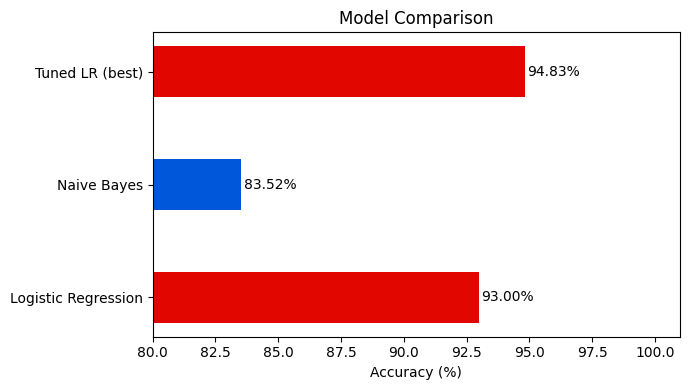

Saved: /content/drive/MyDrive/news_plots/baseline_model_comparison.png

All models saved to Drive


In [ ]:
# Comparison plot
if not os.path.exists(PLOT_BASELINE_CMP):
    X_test_lr  = tfidf.transform(X_test_text)
    models     = ["Logistic Regression", "Naive Bayes", "Tuned LR (best)"]
    accuracies = [
        accuracy_score(y_test, lr_model.predict(X_test_lr))     * 100,
        accuracy_score(y_test, nb_model.predict(X_test_lr))     * 100,
        accuracy_score(y_test, best_model.predict(X_test_best)) * 100,
    ]
    plt.figure(figsize=(7, 4))
    bars = plt.barh(models, accuracies, color=["#E10600","#0057D9","#E10600"], height=0.45)
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f"{acc:.2f}%", va="center", fontsize=10)
    plt.xlim(80, 101)
    plt.xlabel("Accuracy (%)")
    plt.title("Model Comparison")
    plt.tight_layout()
    plt.savefig(PLOT_BASELINE_CMP)
    plt.show()
    print("Saved:", PLOT_BASELINE_CMP)
else:
    print("Skipping comparison plot (already exists)")

print("\nAll models saved to Drive")